# 전처리 & 머신러닝 통합 개인과제

## Part 2. 구매 고객 특성 분석 및 시각화

### 실무 시나리오

전자상거래 기업의 CRM팀은 모든 고객에게 동일한 프로모션을 제공하면서 마케팅 비용이 증가하고 있습니다.  
이에 데이터 분석팀은 Part 1에서 정제한 고객 데이터를 활용하여 **구매율과 구매금액이 높은 고객군을 찾고, 고객의 구매 행동을 설명할 수 있는 주요 변수를 확인**하려고 합니다.

수강생은 데이터 분석 담당자로서 다음 업무를 수행합니다.

1. 고객군별 구매 특성을 비교합니다.
2. 구매 행동의 분포와 변수 간 관계를 시각화합니다.
3. 분석 결과를 바탕으로 Part 3 구매예측 모델에 사용할 Feature 후보를 정리합니다.

> 문제 1~3은 필수 문제입니다.  
> 문제 4는 추가 분석을 위한 심화 문제이며 선택적으로 수행합니다.  
> 차트 종류와 표현 방식은 정해진 하나의 답만 있는 것이 아닙니다. 분석 목적에 적절하고 제목·축·범례가 명확하면 인정합니다.

## 과제 목표

- 전처리된 데이터의 주요 구매 현황을 확인할 수 있습니다.
- 두 개 이상의 기준으로 고객 데이터를 집계하고 집단별 구매 차이를 설명할 수 있습니다.
- 분석 목적에 적합한 차트를 선택하고 기본 시각 요소를 설정할 수 있습니다.
- EDA 결과를 근거로 머신러닝 Feature 후보를 제안할 수 있습니다.

## 사용 환경 및 데이터

- Python 3.X
- pandas, numpy
- `전자상거래_고객구매_전처리완료.csv`

# 문제 1. 주요 고객군의 구매 특성 비교

## 업무 상황

CRM팀은 프로모션 대상을 정하기 위해 어떤 고객군의 구매율과 구매금액이 높은지 확인하려고 합니다.  
전체 평균만 확인하면 집단별 차이를 알기 어렵기 때문에, 고객 특성을 기준으로 구매 실적을 비교해야 합니다.

## 필수 요구사항

1. 전처리 완료 데이터를 불러오고 데이터 크기와 주요 컬럼을 확인하세요.
2. 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.
3. 회원등급, 지역, 연령대, 선호 카테고리 중 적절한 기준을 선택하여 고객군별 구매 특성을 집계하세요.
4. **두 개 이상의 기준을 함께 사용한 그룹 집계**를 1개 이상 수행하세요.
5. 집계 결과를 바탕으로 구매율 또는 평균 구매금액이 높은 고객군을 간단히 설명하세요.

## 힌트

- 고객 수, 구매 고객 수, 구매율, 평균 구매금액, 평균 방문횟수 등을 집계 지표로 활용할 수 있습니다.
- 구매율이 높더라도 고객 수가 매우 적다면 해석에 주의해야 합니다.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("전자상거래_고객구매_전처리완료.csv")

# TODO: 전처리 완료 데이터를 불러와 df에 저장하세요.
df = pd.read_csv(DATA_PATH)

# TODO: 데이터 크기, 주요 컬럼과 앞부분을 확인하세요.
df.shape

(1470, 17)

In [51]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Region', 'MembershipLevel',
       'VisitCount', 'AveragePurchaseAmount', 'TotalPurchaseAmount',
       'SatisfactionScore', 'LastPurchaseDate', 'CouponUsed',
       'PreferredCategory', 'SignupDate', 'Email', 'PurchaseStatus',
       'AgeGroup', 'PurchaseGrade'],
      dtype='str')

In [64]:
df[['CustomerID','MembershipLevel','VisitCount', 'AveragePurchaseAmount', 'TotalPurchaseAmount','LastPurchaseDate', 'CouponUsed','AgeGroup', 'PurchaseGrade']].head()

,CustomerID,MembershipLevel,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,LastPurchaseDate,CouponUsed,AgeGroup,PurchaseGrade
0,CUST101486,Silver,5.0,75000.0,139800.0,2026-02-07,0,40대,Low
1,CUST100113,Basic,7.0,74400.0,159200.0,2026-04-22,0,30대,Low
2,CUST100168,Silver,12.0,185800.0,1055800.0,2026-06-06,0,60대 이상,High
3,CUST101212,VIP,7.0,153900.0,413200.0,2026-05-07,0,40대,Medium
4,CUST100312,Basic,14.0,123700.0,576000.0,2026-04-16,0,30대,High


In [62]:
# TODO: 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.


# customerid 중복 있나 확인
dupli = df['CustomerID'].duplicated().sum()
print(dupli)

# 전체 고객 수, 구매 고객 수, 구매율, 
total_customer = df['CustomerID'].value_counts().sum()
purchase_customer = (df['PurchaseStatus']==1).sum()
purchase_percent = purchase_customer/total_customer * 100

#주요 수치형 변수
main_numeric_columns = ['Age','VisitCount','AveragePurchaseAmount','TotalPurchaseAmount','SatisfactionScore']

print('전체 고객 수: ',total_customer)
print('구매 고객 수: ',purchase_customer)
print('구매율: ',purchase_percent.round(2))

print('주요 수치형 변수의 기초 통계량')
display(df[main_numeric_columns].describe())





0
전체 고객 수:  1470
구매 고객 수:  715
구매율:  48.64
주요 수치형 변수의 기초 통계량


,Age,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore
count,1470.000000,1470.000000,1470.000000,1.470000e+03,1470.000000
mean,39.411905,9.031973,119948.886054,3.875299e+05,3.656602
std,10.759764,2.951099,52201.000665,2.602605e+05,0.746322
min,18.000000,1.000000,5000.000000,5.000000e+03,1.700000
25%,32.000000,7.000000,83250.000000,1.846750e+05,3.200000
50%,39.000000,9.000000,117350.000000,3.340500e+05,3.660150
75%,47.000000,11.000000,150875.000000,5.352750e+05,4.200000
max,69.500000,17.000000,252312.500000,1.061175e+06,5.000000


In [54]:
# COUPON_USED 변수 활용하기 위해 -> 0과 1로 MAPPING
df['CouponUsed'] = df['CouponUsed'].map({'Y': 1, 'N': 0})

In [68]:
# TODO: 고객 특성 한 가지를 기준으로 구매 특성을 집계하세요.
# 지역별 고객 특성
region_summary = df.groupby('Region').agg({
    'VisitCount': ['mean','median'],
    'AveragePurchaseAmount': ['mean','median','sum'],
    'TotalPurchaseAmount': ['mean', 'median', 'sum'],
    'SatisfactionScore': ['mean','median'],
    'PurchaseStatus': ['mean','sum'],   # 구매율
    'CouponUsed': ['mean','sum'],        # 쿠폰 사용률

}).round(2)

display(region_summary)

VisitCount        AveragePurchaseAmount                        \
               mean median                  mean    median         sum   
Region                                                                   
Busan          8.93    9.0             115301.13  107000.0  15335050.0   
Daegu          9.08    9.0             123836.44  127550.0  13126662.5   
Daejeon        8.90    9.0             120293.55  113000.0  18645500.0   
Gwangju        9.31    9.0             121567.77  121700.0  17870462.5   
Gyeonggi       9.01    9.0             116486.99  114600.0  42750725.0   
Incheon        9.40    9.0             117959.72  117650.0  14862925.0   
Seoul          8.94    9.0             123667.76  121750.0  50209112.5   
Unknown        8.67    8.0             117480.83  121750.0   3524425.0   

         TotalPurchaseAmount                        SatisfactionScore         \
                        mean    median          sum              mean median   
Region                                                                         
Busan              387570.30  297800.0   51546850.0              3.63   3.60   
Daegu              435570.52  407750.0   46170475.0              3.65   3.60   
Daejeon            365385.48  320000.0   56634750.0              3.59   3.66   
Gwangju            391294.56  336800.0   57520300.0              3.59   3.60   
Gyeonggi           370393.73  323400.0  135934500.0              3.71   3.70   
Incheon            403306.35  359300.0   50816600.0              3.67   3.63   
Seoul              392697.29  347250.0  159435100.0              3.66   3.66   
Unknown            387011.67  296500.0   11610350.0              3.76   3.70   

         PurchaseStatus      CouponUsed       
                   mean  sum       mean  sum  
Region                                        
Busan              0.46   61       0.50   66  
Daegu              0.57   60       0.39   41  
Daejeon            0.50   78       0.45   70  
Gwangju            0.43   63       0.37   54  
Gyeonggi           0.48  176       0.44  161  
Incheon            0.48   61       0.38   48  
Seoul              0.50  203       0.42  171  
Unknown            0.43   13       0.43   13

In [69]:
# TODO: 두 개 이상의 기준을 함께 사용하여 그룹 집계를 수행하세요.
grade_category_summary = df.groupby(['MembershipLevel', 'PreferredCategory']).agg({
    'VisitCount': ['mean','median'],
    'AveragePurchaseAmount': ['mean','median','sum'],
    'TotalPurchaseAmount': ['mean', 'median', 'sum'],
    'SatisfactionScore': ['mean','median'],
    'PurchaseStatus': ['mean','sum'],   # 구매율
    'CouponUsed': ['mean','sum'],        # 쿠폰 사용률
}).round(2)

display(grade_category_summary)

VisitCount        AveragePurchaseAmount  \
                                        mean median                  mean   
MembershipLevel PreferredCategory                                           
Basic           Beauty                  9.28    9.0              97358.49   
                Electronics             8.74    9.0             143918.32   
                Fashion                 9.05    9.0              82938.46   
                Food                    8.83    9.0              84050.43   
                Home                    8.77    8.0              75744.83   
                Sports                  9.45    9.5              82132.93   
                Unknown                 9.67   10.0              86222.22   
Gold            Beauty                  8.72    9.0             148768.52   
                Electronics            10.17   10.0             208650.35   
                Fashion                 9.36    9.0             137466.67   
                Food                    8.26    8.0             138176.74   
                Home                    8.49    9.0             146616.28   
                Sports                  9.10   10.0             138596.55   
                Unknown                 7.33    8.0             118300.00   
Silver          Beauty                  8.83    9.0             120146.03   
                Electronics             9.01    9.0             168331.25   
                Fashion                 9.06    9.0             102029.73   
                Food                    8.88    9.0              99380.47   
                Home                    8.97    9.0             105103.39   
                Sports                  9.77   10.0             123764.52   
                Unknown                10.45   10.0             113309.09   
VIP             Beauty                 10.43   10.0             198058.93   
                Electronics             9.06    9.0             236216.41   
                Fashion                 9.82   10.0             185309.66   
                Food                    9.35    9.0             189412.50   
                Home                    7.88    8.0             181606.62   
                Sports                  8.68    8.0             179832.24   
                Unknown                 7.50    7.5             184906.25   

                                                         TotalPurchaseAmount  \
                                      median         sum                mean   
MembershipLevel PreferredCategory                                              
Basic           Beauty              99600.00  10320000.0           356018.63   
                Electronics        143800.00  18853300.0           438790.84   
                Fashion             81950.00  11860200.0           290140.91   
                Food                84000.00   9665800.0           276422.39   
                Home                74800.00   6589800.0           243217.24   
                Sports              83150.00   6734900.0           259760.98   
                Unknown            100600.00    776000.0           244588.89   
Gold            Beauty             144000.00   8033500.0           467749.54   
                Electronics        206600.00   7511412.5           612710.42   
                Fashion            138500.00   9072800.0           463622.73   
                Food               135900.00   5941600.0           393966.86   
                Home               152600.00   6304500.0           437141.28   
                Sports             139600.00   4019300.0           439644.83   
                Unknown            109400.00    354900.0           366866.67   
Silver          Beauty             121600.00   7569200.0           402534.92   
                Electronics        166675.00  12456512.5           528200.00   
                Fashion            101300.00  11325300.0           328449.10   
                Food                95475.00  

### 문제 1 결과 정리

- 전체 구매 현황: 전체 고객 수는 1470명 / 구매 고객수: 715 => 따라서 구매율은 약 48.64% 
- 구매율이 높은 고객군: 
    - 지역별로 보았을 때 구매율이 가장 높았던 것은 대구(0.57)였다.
    - 회원등급과 선호 카테고리를 같이 보았을 때 구매율이 가장 높았던 고객군은 VIP 회원등급의 BEAUTY와 Unknow 카테고리(1) 였다.
- 평균 구매금액이 높은 고객군: 
    - 지역별로 보았을 때 평균 구매금액이 높은 고객군은 대구(123836.44)였다.
    - 회원등급과 선호 카테고리르 같이 보았을 때 구매율이 가장 높았던 고객군은 VIP의 Electronics(236216.41)였다.
- 고객 수를 함께 고려했을 때 주의할 점:
    - 구매율이나 평균 구매금액만 보면 우수 고객군으로 보이더라도, 실제로는 해당 그룹의 고객 수 자체가 매우 적어 통계저그올 신뢰하기 어려울 수 있다.
    - 예를 들어 지역별 구매자 수를 보면 대구는 60명에 불과하지만, 서울 203명 경기 176명으로 훨씬 많닫. 즉 대구는 구매율과 평균 구매금액이 높지만 표본 자체가 작아 전체 매출에 기여하는 비중은 크지 않을 수 있다.

# 문제 2. 구매 행동의 분포와 관계 시각화

## 업무 상황

고객군별 평균만으로는 실제 데이터가 어느 구간에 집중되어 있는지, 일부 극단값이 평균에 영향을 주는지 알기 어렵습니다.  
CRM팀이 결과를 쉽게 이해할 수 있도록 구매 행동의 분포, 고객군 간 차이, 변수 간 관계를 시각화해야 합니다.

## 필수 요구사항

1. 구매금액, 방문횟수, 만족도 등 주요 수치형 변수 중 하나 이상의 분포를 시각화하세요.
2. 회원등급, 구매 여부 등 고객 집단별 차이를 비교할 수 있는 차트를 작성하세요.
3. 두 수치형 변수의 관계를 확인할 수 있는 차트를 작성하세요.
4. 모든 차트에 분석 내용을 이해할 수 있는 제목과 축 이름을 표시하고, 필요한 경우 범례를 추가하세요.
5. 차트에서 확인한 주요 패턴을 간단히 설명하세요.

## 힌트

- 분포 확인에는 히스토그램이나 박스플롯을 사용할 수 있습니다.
- 집단 비교에는 막대그래프나 그룹별 박스플롯을 사용할 수 있습니다.
- 수치형 변수 관계에는 산점도를 사용할 수 있습니다.

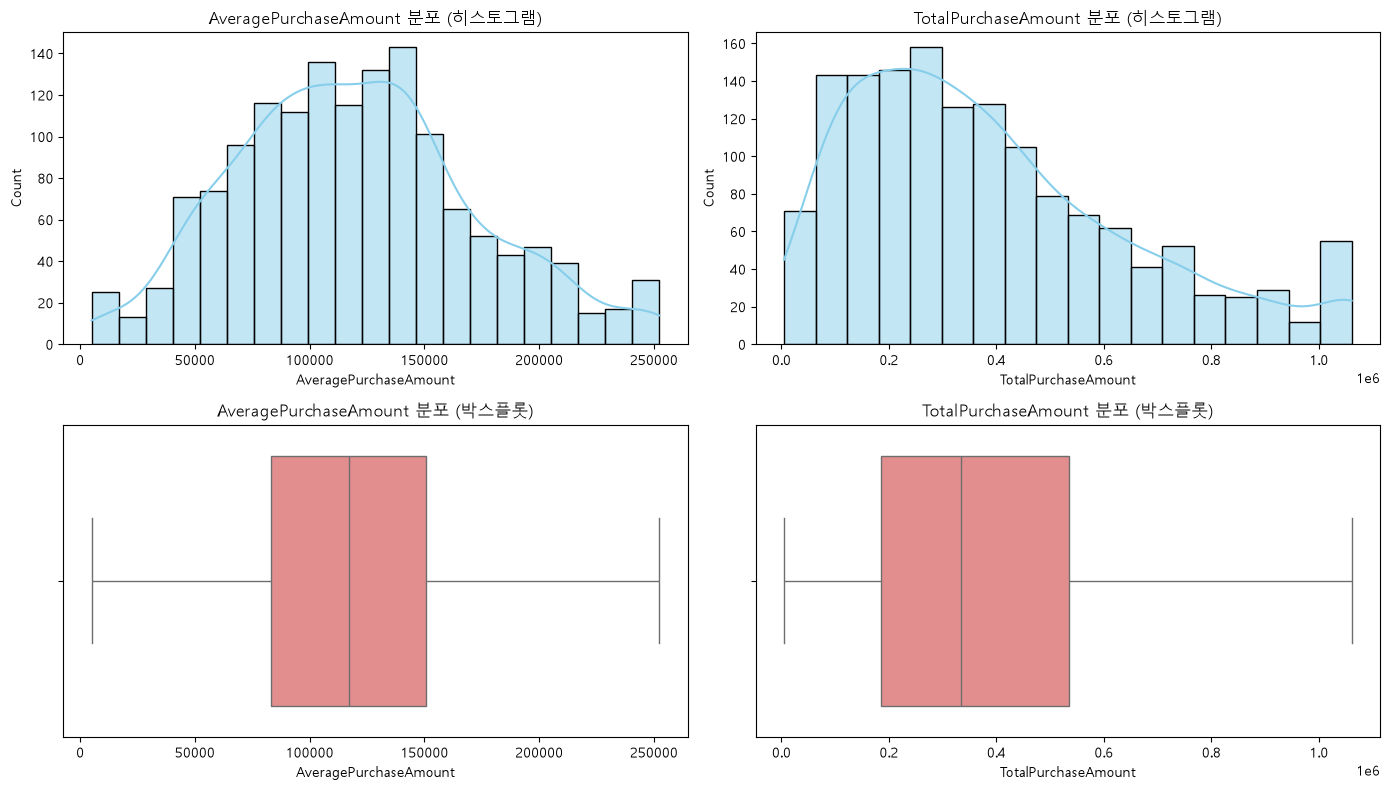

In [70]:
# TODO: 주요 수치형 변수의 분포를 시각화하세요.
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지 (Windows 기준, Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

purchase_cols = ['AveragePurchaseAmount', 'TotalPurchaseAmount']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(purchase_cols):
    # 히스토그램 + KDE
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'{col} 분포 (히스토그램)')
    
    # 박스플롯
    sns.boxplot(x=df[col], ax=axes[1, i], color='lightcoral')
    axes[1, i].set_title(f'{col} 분포 (박스플롯)')

plt.tight_layout()
plt.show()

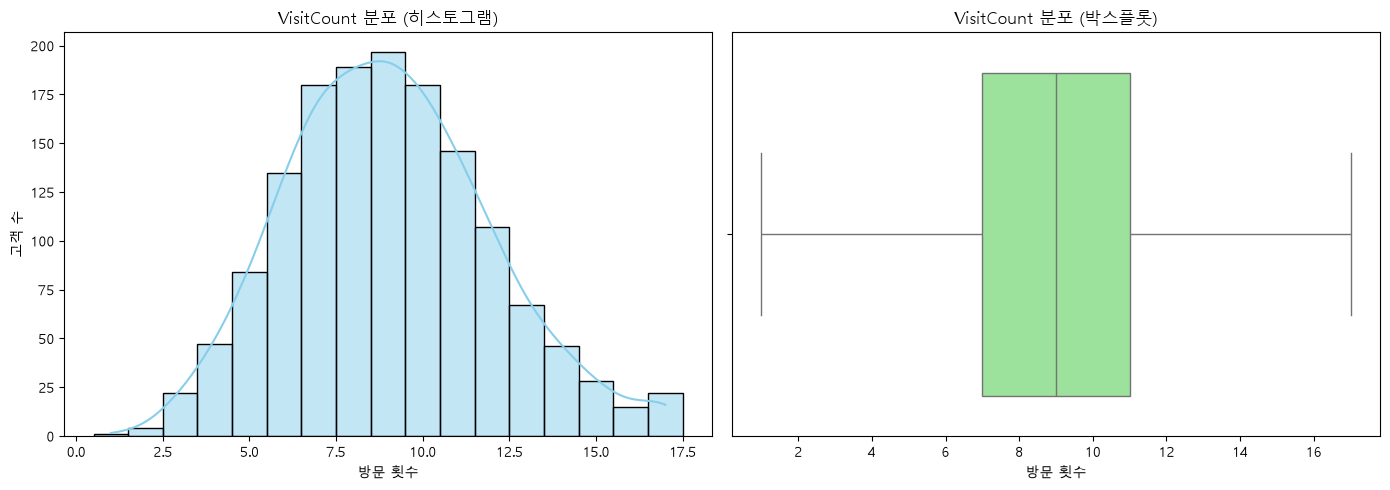

In [ ]:
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기준. Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
sns.histplot(df['VisitCount'], discrete=True, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('VisitCount 분포 (히스토그램)')
axes[0].set_xlabel('방문 횟수')
axes[0].set_ylabel('고객 수')

# 박스플롯
sns.boxplot(x=df['VisitCount'], ax=axes[1], color='lightgreen')
axes[1].set_title('VisitCount 분포 (박스플롯)')
axes[1].set_xlabel('방문 횟수')

plt.tight_layout()
plt.show()

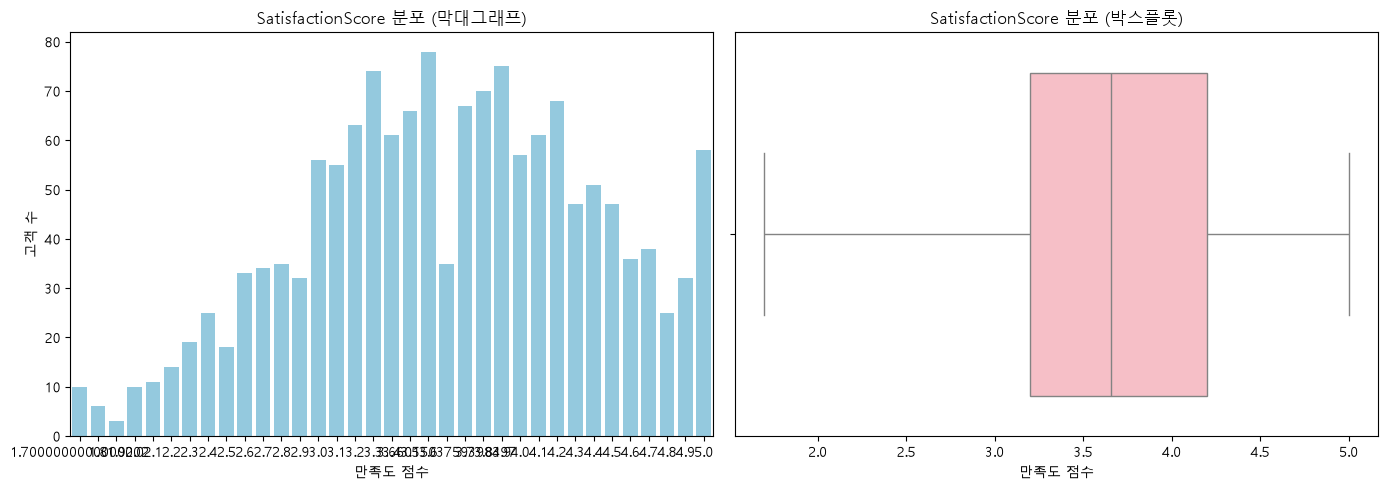

In [72]:
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기준. Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 카운트플롯 (점수별 인원수)
sns.countplot(x='SatisfactionScore', data=df, ax=axes[0], color='skyblue')
axes[0].set_title('SatisfactionScore 분포 (막대그래프)')
axes[0].set_xlabel('만족도 점수')
axes[0].set_ylabel('고객 수')

# 박스플롯
sns.boxplot(x=df['SatisfactionScore'], ax=axes[1], color='lightpink')
axes[1].set_title('SatisfactionScore 분포 (박스플롯)')
axes[1].set_xlabel('만족도 점수')

plt.tight_layout()
plt.show()

In [ ]:
# TODO: 고객 집단별 구매 차이를 비교하는 차트를 작성하세요.


In [ ]:
# TODO: 두 수치형 변수의 관계를 확인하는 차트를 작성하세요.

### 문제 2 결과 정리

- 주요 변수의 분포 특징:
- 
- 고객 집단별 차이:
- 두 변수 사이에서 확인한 관계:
- 시각화 결과가 고객 분석에 주는 의미:


# 문제 3. 구매예측 모델링 Feature 후보 정리

## 업무 상황

Part 3에서는 고객의 구매 여부를 예측하는 머신러닝 모델을 개발합니다.  
모델에 모든 컬럼을 그대로 넣기보다, 이번 EDA에서 구매 행동과 관련성이 확인된 변수와 제외해야 할 변수를 구분해야 합니다.

## 필수 요구사항

1. 수치형 변수와 `PurchaseStatus`의 관계를 확인할 수 있는 표 또는 시각화를 작성하세요.
2. 문제 1과 문제 2의 분석 결과를 바탕으로 모델링에 사용할 Feature 후보를 정리하세요.
3. 고객 식별자처럼 일반적인 구매 패턴 학습에 적절하지 않은 컬럼을 제외 후보로 구분하세요.
4. 각 Feature 후보를 선정한 근거를 EDA 결과와 연결하여 간단히 설명하세요.

## 힌트

- 상관계수는 수치형 변수 사이의 선형 관계를 확인하는 참고 자료입니다.
- 상관계수가 낮더라도 범주형 변수나 비선형 관계를 가진 변수는 모델에 유용할 수 있습니다.
- 고객 ID와 같은 고유 식별자는 새로운 고객의 구매 패턴을 일반화하는 데 적절하지 않을 수 있습니다.

In [ ]:
# TODO: 수치형 변수와 PurchaseStatus의 관계를 확인하세요.

In [ ]:
# TODO: EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리하세요.

### 문제 3 결과 정리

#### 모델링 Feature 후보

- 수치형 Feature:
- 범주형 Feature:
- 선정 근거:

#### 제외 후보

- 제외할 컬럼:
- 제외 이유:



# (심화)문제 4. 분석 결과의 심화 해석

## 업무 상황

CRM팀은 기본 분석 결과를 실제 마케팅과 구매예측 모델에 적용하기 전에,
고객군별 결과의 활용 가능성과 해석상의 주의점, 모델링 변수 구성의 위험 요소를 추가로 확인하려고 합니다.

## 요구사항

### 4-1. 고객군 활용 방안 제안

1. 문제 1의 집계 결과를 바탕으로 우선 관리할 고객군을 한 개 이상 선정하세요.
2. 해당 고객군을 선정한 근거를 구매율, 평균 구매금액, 고객 수 등의 지표와 연결하여 작성하세요.
3. 선정한 고객군에 적용할 수 있는 마케팅 활용 방안을 한 가지 이상 제안하세요.

### 4-2. 시각화 결과 해석 시 주의점

1. 문제 2의 분포 또는 집단 비교 차트에서 확인되는 치우침, 극단값, 집단별 차이 중 하나 이상을 설명하세요.
2. 해당 결과를 해석할 때 주의해야 할 점을 작성하세요.
3. 필요하다면 기존 분석을 보완하는 추가 차트를 한 개 작성하세요.

### 4-3. 모델링 Feature 위험 요소 검토

1. 서로 비슷한 정보를 제공하여 중복 가능성이 있는 변수를 한 쌍 이상 제시하세요.
2. 예측 시점에 사용할 수 없거나 구매 결과를 직접 반영하여 데이터 누수 가능성이 있는 변수를 검토하세요.
3. 최종 Feature 구성을 수치형 변수와 범주형 변수로 나누어 정리하세요.



## 심화 문제 결과 작성

### 4-1. 고객군 활용 방안

- 우선 관리할 고객군:
- 선정 근거:
- 제안할 마케팅 활용 방안:

### 4-2. 시각화 해석 시 주의점

- 확인한 분포 또는 집단 차이:
- 해석 시 주의할 점:
- 추가로 작성한 차트와 확인 결과:

### 4-3. Feature 위험 요소

- 중복 정보 가능성이 있는 변수:
- 데이터 누수 가능성이 있는 변수:
- 최종 수치형 Feature:
- 최종 범주형 Feature:



# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 전체 구매 현황 | 전체 고객 수, 구매 고객 수, 구매율, 주요 기초 통계량 |
| 고객군별 집계표 | 단일 기준 및 두 개 이상 기준의 그룹 집계 |
| 고객군 해석 | 구매율 또는 평균 구매금액이 높은 고객군 설명 |
| 주요 시각화 | 분포, 고객 집단 비교, 두 수치형 변수 관계 차트 |
| Feature 후보 | 모델링에 사용할 Feature와 제외 후보 및 선정 근거 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 고객군 활용 방안 | 우선 관리 고객군과 마케팅 제안 |
| 시각화 해석 주의점 | 치우침·극단값·집단 차이 해석과 주의사항 |
| Feature 위험 검토 | 중복 정보와 데이터 누수 가능성 검토 |
| 최종 Feature 구성 | 수치형·범주형 Feature 구분 |

# 제출 전 체크리스트

## 필수 체크리스트

- [ ] Part 1 전처리 완료 데이터를 사용했습니다.
- [ ] 전체 구매 현황과 주요 기초 통계량을 확인했습니다.
- [ ] 두 개 이상의 기준을 사용한 그룹 집계를 수행했습니다.
- [ ] 구매 특성이 두드러진 고객군을 설명했습니다.
- [ ] 분포, 집단 비교, 변수 관계를 확인할 수 있는 시각화를 작성했습니다.
- [ ] 차트에 제목, 축 이름과 필요한 범례를 표시했습니다.
- [ ] EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리했습니다.

## 심화 체크리스트

- [ ] 우선 관리할 고객군과 마케팅 활용 방안을 제안했습니다.
- [ ] 분포 또는 집단 차이를 해석할 때의 주의점을 설명했습니다.
- [ ] 필요에 따라 추가 차트를 작성했습니다.
- [ ] 중복 정보 가능성이 있는 변수를 검토했습니다.
- [ ] 데이터 누수 가능성이 있는 변수를 검토했습니다.
- [ ] 최종 Feature를 수치형과 범주형으로 구분했습니다.
